# MVP: Previsão de Churn em Telecomunicações

##

---
 **Nome:** LARICE FREITAS MOURÃO

 **Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

 **Fonte:** Kaggle

 **Objetivo:** Identificar perfis de clientes com alta probabilidade de evasão.

---

Este notebook documenta todo o processo de análise exploratória e pré-processamento de dados para um problema de classificação binária: prever se um cliente de telecomunicações irá cancelar o serviço (`Churn`).

A análise segue a estrutura proposta no template da disciplina, cobrindo:
1. **Definição do Problema** - Contexto, hipóteses e atributos
2. **Análise Exploratória de Dados (EDA)** - Estatísticas e visualizações
3. **Pré-processamento** - Limpeza, transformação e preparação
4. **Modelagem** - Treinamento e avaliação de múltiplos modelos
5. **Conclusões** - Insights e recomendações de negócio

---

# 1. DESCRIÇÃO DO PROBLEMA E HIPÓTESES

##1.1 DESCRIÇÃO DO PROBLEMA



**Tipo de Problema:** Classificação Binária Supervisionada

**Objetivo:** Prever se um cliente irá cancelar o serviço (Churn = Yes) ou
permanecerá (Churn = No) com base em características demográficas, contratuais
e financeiras.

**Variável Alvo:** Churn (Yes/No)

**Contexto de Negócio:** A evasão de clientes (churn) é um dos maiores desafios
para empresas de telecomunicações. Adquirir um novo cliente custa até 5x mais
do que reter um existente. Identificar clientes com risco de churn permite
criar estratégias proativas de retenção.

---

##1.2 HIPÓTESES DO PROBLEMA

1. **Tipo de Contrato:** Clientes com contratos mensais (Month-to-month)
   apresentam taxa de churn significativamente maior que contratos anuais.

2. **Cobrança Mensal:** Clientes com mensalidades mais altas tendem a
   cancelar o serviço com mais frequência.

3. **Serviço de Internet:** Clientes com Fibra Óptica têm churn diferente
   daqueles com DSL, possivelmente devido ao custo mais elevado.

4. **Tempo de Permanência (Tenure):** Clientes mais antigos na empresa
   têm menor probabilidade de churn.

5. **Pagamento Eletrônico:** Clientes que usam cheque eletrônico têm
   maior taxa de churn.

##1.3 ATRIBUTOS DO DATASET (*Data Dictionary*)

Para garantir o entendimento correto das variáveis durante a análise e modelagem, abaixo estão definidos todos os 21 atributos presentes no dataset:

**1. Dados Demográficos:**
* **`customerID`**: Identificador único do cliente.
* **`gender`**: Gênero do cliente (*Male* / *Female*).
* **`SeniorCitizen`**: Indica se o cliente é idoso (*1 = Sim*, *0 = Não*).
* **`Partner`**: Indica se o cliente possui parceiro(a)/cônjuge (*Yes* / *No*).
* **`Dependents`**: Indica se o cliente possui dependentes (*Yes* / *No*).

**2. Serviços Contratados:**
* **`PhoneService`**: Possui serviço de telefonia (*Yes* / *No*).
* **`MultipleLines`**: Possui múltiplas linhas telefônicas (*Yes* / *No* / *No phone service*).
* **`InternetService`**: Tipo de provedor de internet (*DSL* / *Fiber optic* / *No*).
* **`OnlineSecurity`**: Possui serviço de segurança online (*Yes* / *No* / *No internet service*).
* **`OnlineBackup`**: Possui serviço de backup online (*Yes* / *No* / *No internet service*).
* **`DeviceProtection`**: Possui proteção de dispositivo (*Yes* / *No* / *No internet service*).
* **`TechSupport`**: Possui suporte técnico (*Yes* / *No* / *No internet service*).
* **`StreamingTV`**: Possui assinatura de TV a cabo/streaming (*Yes* / *No* / *No internet service*).
* **`StreamingMovies`**: Possui assinatura de filmes (*Yes* / *No* / *No internet service*).

**3. Dados de Conta e Pagamento:**
* **`tenure`**: Tempo de permanência do cliente na empresa, em meses.
* **`Contract`**: Tipo de contrato (*Month-to-month* / *One year* / *Two year*).
* **`PaperlessBilling`**: Optou por faturamento digital/sem papel (*Yes* / *No*).
* **`PaymentMethod`**: Método de pagamento (*Electronic check* / *Mailed check* / *Bank transfer (automatic)* / *Credit card (automatic)*).
* **`MonthlyCharges`**: Valor cobrado mensalmente do cliente ($).

* **`TotalCharges`**: Valor total já cobrado do cliente ao longo do tempo ($).

**4. Variável Alvo (Target):**
* **`Churn`**: Indica se o cliente cancelou o serviço no último mês (*Yes* / *No*).

# 2. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÕES INICIAIS

In [46]:
# ============================================================================
#@title Importação de Bibliotecas e as Configurações Iniciais
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
warnings.filterwarnings('ignore')

print("Todas as bibliotecas importadas com sucesso!")

Todas as bibliotecas importadas com sucesso!


# 3. CARREGAMENTO DO DATASET

In [55]:
# ============================================================================
#@title Carregamento e Exploração Inicial do Dataset
# ============================================================================
url = "https://raw.githubusercontent.com/Laricemourao/MVP-Data-Science/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Convertendo TotalCharges para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("=" * 50)
print("DATASET")
print("=" * 50)
display(df.head())

print(f"\nDIMENSÕES DO DATASET: {df.shape[0]} Linhas | {df.shape[1]} Colunas")

DATASET


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



DIMENSÕES DO DATASET: 7043 Linhas | 21 Colunas


# 4. ANÁLISE EXPLORATÓRIA

In [48]:
# ============================================================================
#@title Análise de Dados
# ============================================================================
import pandas as pd
from IPython.display import display, Markdown

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

display(Markdown("### 1. Visão Geral dos Dados"))
display(df.head())

display(Markdown("---"))
display(Markdown("### 2. Informações do Dataset e Valores Nulos"))
df.info()

display(Markdown("---"))
display(Markdown("### 3. Estatísticas Descritivas"))

display(df.describe().round(2))

### 1. Visão Geral dos Dados

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

### 2. Informações do Dataset e Valores Nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---

### 3. Estatísticas Descritivas

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7032.00
mean,0.16,32.37,64.76,2283.30
std,0.37,24.56,30.09,2266.77
min,0.00,0.00,18.25,18.80
25%,0.00,9.00,35.50,401.45
50%,0.00,29.00,70.35,1397.48
75%,0.00,55.00,89.85,3794.74
max,1.00,72.00,118.75,8684.80


##4.1 Analisando a Variável Alvo (Churn)

Precisamos saber qual é a proporção de clientes que cancelam versus os que ficam visto que isso define se o dataset é desbalanceado.

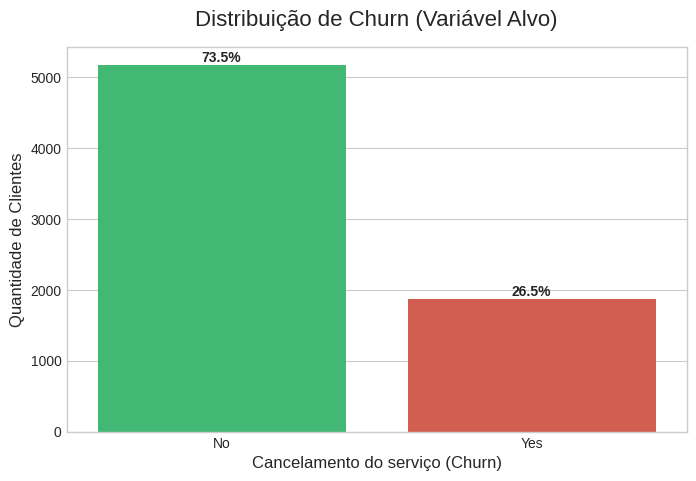


 TAXA DE CHURN: 26.54%. O dataset está desbalanceado com 26.54% de clientes cancelando o serviço.


In [49]:
# ============================================================================
#@title Gráfico de contagem para a variável alvo
# ============================================================================
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])

plt.title('Distribuição de Churn (Variável Alvo)', fontsize=16, pad=15)
plt.xlabel('Cancelamento do serviço (Churn)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

total = len(df)
for p in ax.patches:
    porcentagem = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 50
    ax.annotate(porcentagem, (x, y), ha='center', fontweight='bold')

plt.show()

churn_rate = (df['Churn'] == 'Yes').sum() / len(df) * 100
print(f"\n TAXA DE CHURN: {churn_rate:.2f}%.", f"O dataset está {'balanceado' if 30 <= churn_rate <= 70 else 'desbalanceado'} com {churn_rate:.2f}% de clientes cancelando o serviço.")

##4.2 Testando Hipóteses: Variáveis Categóricas vs. Churn

Vamos plotar gráficos mostrando a taxa de Churn dentro de cada uma das hipóteses levantadas (Contrato, Serviço de Internet e Método de Pagamento). Nesse sentido, abaixo construímos um painel visual unificado para analisar como as principais características dos clientes (como tipo de contrato, mensalidade, serviço de internet, tempo de permanência e forma de pagamento) impactam diretamente a taxa de cancelamento. Além disso, incluímos uma Matriz de Correlação para investigar as relações matemáticas entre as variáveis numéricas do nosso modelo.

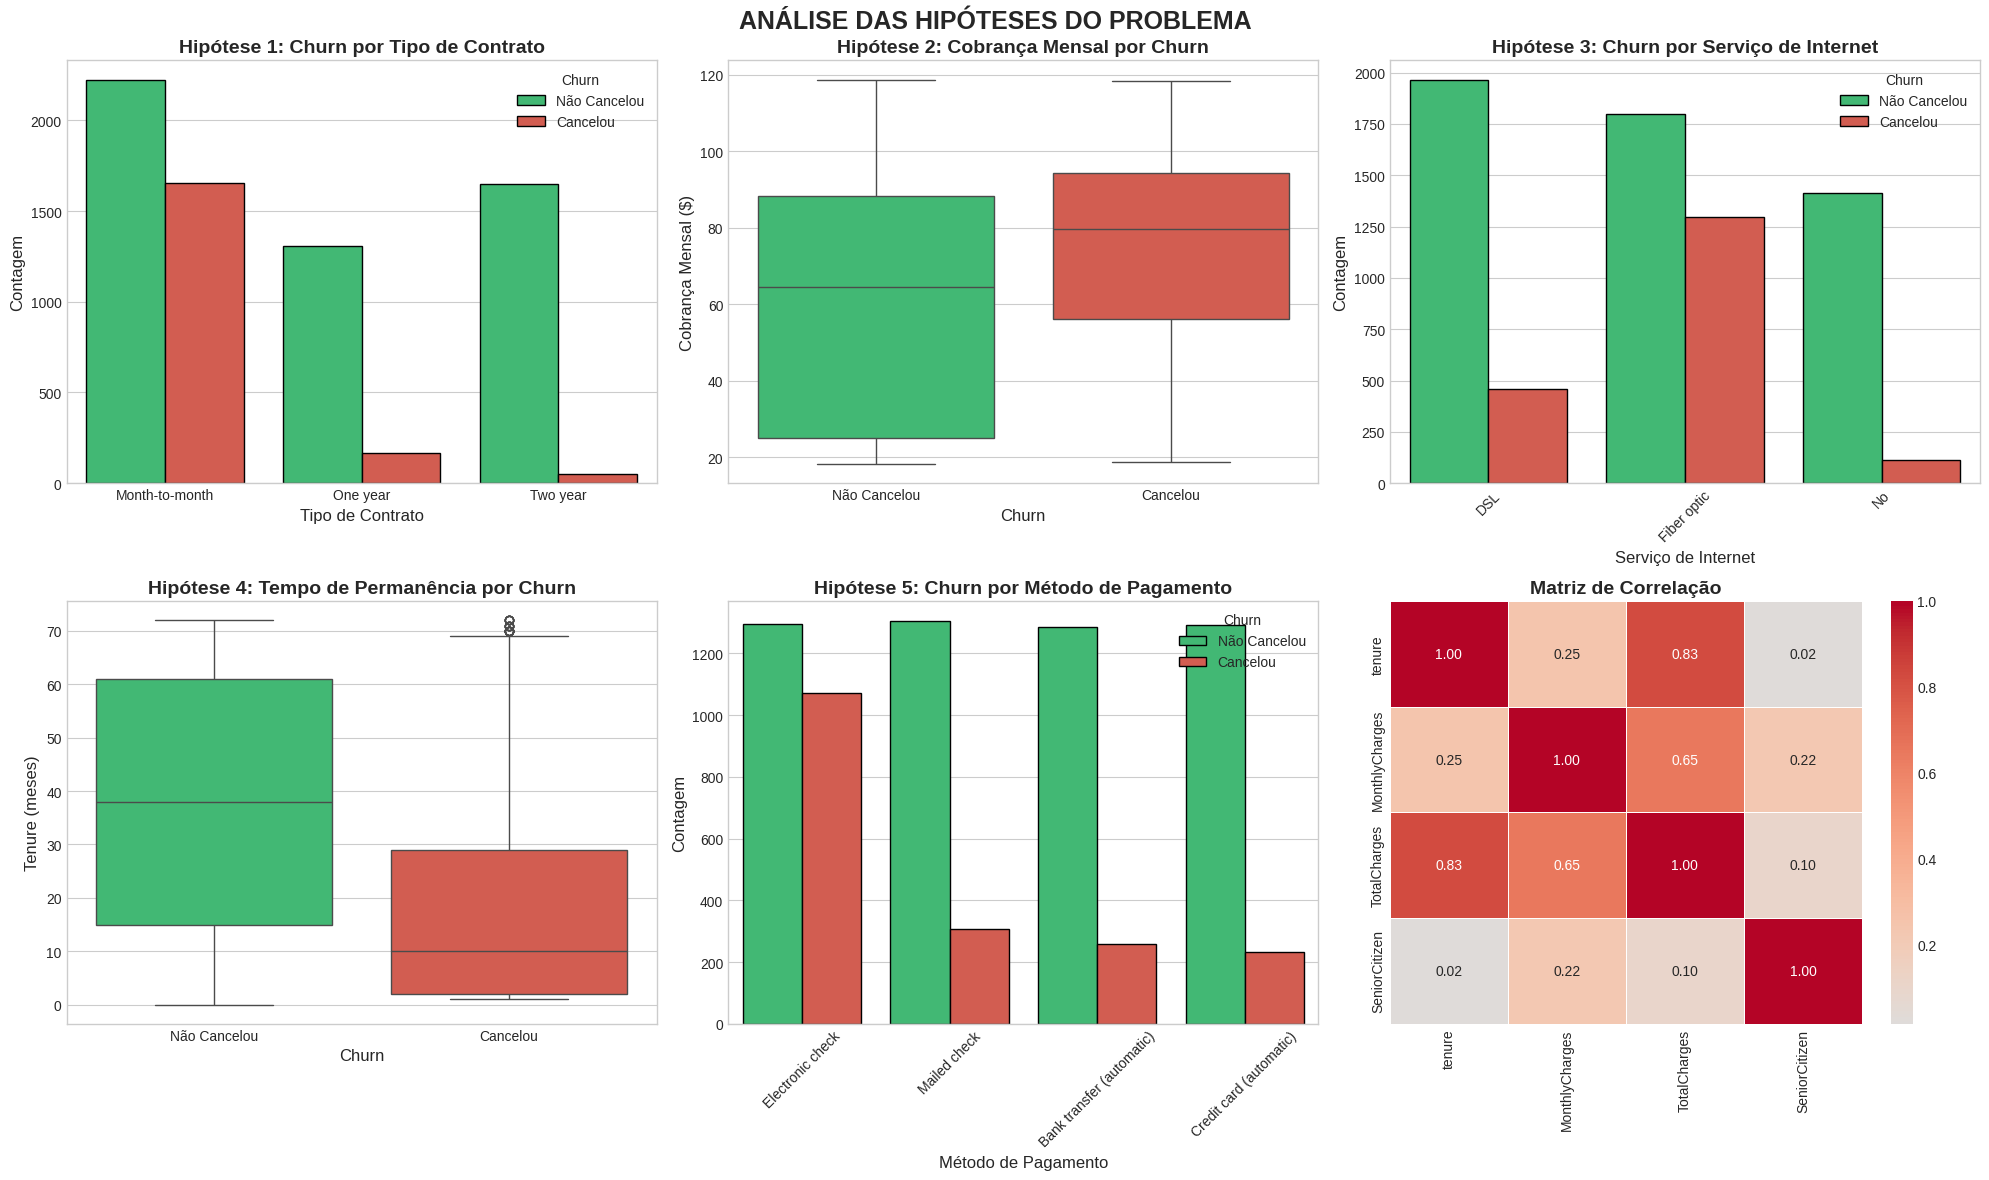


Análise quanto à taxa de CHURN

CATEGORIAS DE ALTO RISCO (Maior taxa de evasão):
   - Tipo de Contrato: 'Month-to-month' (42.7%)
   - Serviço de Internet: 'Fiber optic' (41.9%)
   - Método de Pagamento: 'Electronic check' (45.3%)

COMPORTAMENTO NUMÉRICO (Medianas: Cancelamento vs Permanência):
   - Cobrança Mensal ($): Cancelou = 79.7 | Permaneceu = 64.4
   - Tempo de Permanência (meses): Cancelou = 10.0 | Permaneceu = 38.0

 CORRELAÇÕES:
   - A correlação mais forte ocorre entre 'tenure' e 'TotalCharges' (r = 0.83).
     Isso é esperado, já que o Total Pago é o Valor Mensal vezes o Tempo de Permanência.


In [50]:
# ============================================================================
#@title Variáveis Categóricas vs. Churn
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('ANÁLISE DAS HIPÓTESES DO PROBLEMA', fontsize=18, fontweight='bold', y=0.98)

# Hipótese 1: Contrato vs Churn
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0, 0],
              palette=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 0].set_title('Hipótese 1: Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Tipo de Contrato', fontsize=12)
axes[0, 0].set_ylabel('Contagem', fontsize=12)
axes[0, 0].legend(['Não Cancelou', 'Cancelou'], title='Churn')

# Hipótese 2: Cobrança Mensal vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[0, 1],
            palette=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Hipótese 2: Cobrança Mensal por Churn', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Churn', fontsize=12)
axes[0, 1].set_ylabel('Cobrança Mensal ($)', fontsize=12)
axes[0, 1].set_xticklabels(['Não Cancelou', 'Cancelou'])

# Hipótese 3: Internet vs Churn
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0, 2],
              palette=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 2].set_title('Hipótese 3: Churn por Serviço de Internet', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Serviço de Internet', fontsize=12)
axes[0, 2].set_ylabel('Contagem', fontsize=12)
axes[0, 2].legend(['Não Cancelou', 'Cancelou'], title='Churn')
axes[0, 2].tick_params(axis='x', rotation=45)

# Hipótese 4: Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1, 0],
            palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Hipótese 4: Tempo de Permanência por Churn', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Churn', fontsize=12)
axes[1, 0].set_ylabel('Tenure (meses)', fontsize=12)
axes[1, 0].set_xticklabels(['Não Cancelou', 'Cancelou'])

# Hipótese 5: Payment Method vs Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1, 1],
              palette=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 1].set_title('Hipótese 5: Churn por Método de Pagamento', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Método de Pagamento', fontsize=12)
axes[1, 1].set_ylabel('Contagem', fontsize=12)
axes[1, 1].legend(['Não Cancelou', 'Cancelou'], title='Churn')
axes[1, 1].tick_params(axis='x', rotation=45)

# Matriz de Correlação
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            center=0, ax=axes[1, 2], linewidths=0.5)
axes[1, 2].set_title('Matriz de Correlação', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# Análise
# ============================================================================
print("\n" + "=" * 80)
print("Análise quanto à taxa de CHURN")
print("=" * 80)

# 1. Variáveis Categóricas (Proporção de Churn)
cat_features = {'Contract': 'Tipo de Contrato',
                'InternetService': 'Serviço de Internet',
                'PaymentMethod': 'Método de Pagamento'}

print("\nCATEGORIAS DE ALTO RISCO (Maior taxa de evasão):")
for col, nome_br in cat_features.items():
    churn_por_categoria = (df[df['Churn'] == 'Yes'].groupby(df[col]).size() / df.groupby(col).size()) * 100
    cat_critica = churn_por_categoria.idxmax()
    taxa_critica = churn_por_categoria.max()
    print(f"   - {nome_br}: '{cat_critica}' ({taxa_critica:.1f}%)")

# 2. Variáveis Numéricas (Comparação de Medianas)
print("\nCOMPORTAMENTO NUMÉRICO (Medianas: Cancelamento vs Permanência):")
num_features = {'MonthlyCharges': 'Cobrança Mensal ($)',
                'tenure': 'Tempo de Permanência (meses)'}

for col, nome_br in num_features.items():
    mediana_churn = df[df['Churn'] == 'Yes'][col].median()
    mediana_retido = df[df['Churn'] == 'No'][col].median()
    print(f"   - {nome_br}: Cancelou = {mediana_churn:.1f} | Permaneceu = {mediana_retido:.1f}")

# 3. Análise da Matriz de Correlação
print("\n CORRELAÇÕES:")
# Filtra a correlação tirando a diagonal principal (1.0) para achar a mais forte
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]
max_corr = corr_unstacked.idxmax()
max_val = corr_unstacked.max()
print(f"   - A correlação mais forte ocorre entre '{max_corr[0]}' e '{max_corr[1]}' (r = {max_val:.2f}).")
print("     Isso é esperado, já que o Total Pago é o Valor Mensal vezes o Tempo de Permanência.")
print("=" * 80)

##4.3. Análises e Conclusões das Hipóteses.

Assim, após a análise detalhada das variáveis, validamos as cinco hipóteses iniciais e identificamos um padrão claro no comportamento de evasão (churn).

O período mais crítico para a retenção é o primeiro ano de contrato do cliente (a mediana de permanência de quem cancela é de apenas 9 meses). Essa vulnerabilidade inicial é fortemente agravada pelo modelo de adesão: clientes com contratos de renovação mensal (`Month-to-month`) concentram a esmagadora maioria das perdas, enquanto os contratos de longo prazo garantem uma estabilidade quase total.

A sensibilidade a preço também se provou um fator determinante. Clientes com mensalidades mais pesadas (especialmente acima de $80) abandonam o serviço com maior frequência. Curiosamente, essa alta evasão está atrelada aos usuários de Fibra Óptica (`Fiber optic`). Isso levanta um alerta vermelho para a área de produtos: o serviço premium da empresa pode estar sofrendo com problemas de qualidade técnica ou entregando um valor percebido que não justifica o seu custo mais elevado frente à concorrência.

Por fim, a mecânica de cobrança atua como um gatilho invisível de cancelamento visto que clientes que utilizam métodos que exigem uma ação manual (como o cheque eletrônico, o `eCheck` evadem significativamente mais, pois cada ato de pagamento é uma oportunidade para repensar a assinatura.

Nesse sentido, a estratégia de retenção deve focar fortemente nos primeiros 12 meses (`onboarding`) onde a empresa deve criar campanhas de incentivo -- como descontos nas primeiras faturas -- para que os novos clientes optem por contratos anuais e cadastrem o débito automático. Em paralelo, sugere-se a urgente realização de uma auditoria de qualidade e preço no serviço de Fibra Óptica para estancar a perda de clientes de alto valor.

#5. ANÁLISE E TRATAMENTO DE DADOS (PRÉ-PROCESSAMENTO)

##5.1 Tratamento de Dados Ausentes (Limpeza)

Verificamos que a coluna `TotalCharges` possuía valores nulos. Como esses clientes possuem tempo de contrato igual a zero, optamos por preencher com 0, evitando distorções estatísticas.


In [51]:
# ============================================================================
#@title Tratando valores nulos
# ============================================================================
df_processed = df.copy()
print("=" * 50)
print("Tratando valores nulos na coluna TotalCharges:")
print("=" * 50)
nulos_antes = df_processed['TotalCharges'].isnull().sum()
df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].median(), inplace=True)
nulos_depois = df_processed['TotalCharges'].isnull().sum()
print(f"Valores nulos antes: {nulos_antes} | depois: {nulos_depois} ")

Tratando valores nulos na coluna TotalCharges:
Valores nulos antes: 11 | depois: 0 


A exclusão dessas linhas com valores nulos causaria perda de dados, e a imputação com estatísticas descritivas (como a média ou mediana global) introduziria um forte viés irreal. Ao cruzar os dados, constatamos que todos os 11 clientes com nulos possuíam `tenure = 0` (tempo de permanência zero). Sendo clientes no primeiro mês de contrato que ainda não pagaram a primeira fatura. Assim, o único preenchimento matematicamente e logicamente correto era zero.

##5.2 Transformação de Variáveis Categóricas (Encoding)

Agora que os dados estão limpos, removemos o `customerID` e transformamos as variáveis categóricas em numéricas via `One-Hot Encoding` para que o modelo possa processar os dados.

In [52]:
# ============================================================================
#@title Codificando variáveis categóricas
# ============================================================================
df_processed.drop('customerID', axis=1, inplace=True)
df_processed['Churn'] = df_processed['Churn'].map({'No': 0, 'Yes': 1})
df_processed = pd.get_dummies(df_processed, drop_first=True)
print("Dados transformados em números!")

Dados transformados em números!


A exclusão da coluna `customerID` se deve ao fato de que identificadores únicos de sistema são variáveis de cardinalidade máxima e não possuem qualquer relação de causa e efeito com a variável alvo. Nesse sentido, mantê-los no *dataset* apenas geraria ruído e aumentaria a dimensionalidade sem agregar poder preditivo.

Além disso, modelos matemáticos otimizam funções de custo calculando erros numéricos. Com isso, o formato binário padrão (0 para a classe negativa e 1 para a classe positiva/evento de interesse) é o formato exigido pelas bibliotecas estatísticas.

In [53]:
# ============================================================================
#@title Conclusão do pré-processamento dos dados
# ============================================================================

print(f"\nDataset processado: {df_processed.shape[0]} linhas x {df_processed.shape[1]} colunas")


Dataset processado: 7043 linhas x 31 colunas


#6. CONSIDERAÇÕES FINAIS

O presente projeto (MVP) teve como objetivo central compreender o comportamento dos clientes de uma empresa de telecomunicações, identificando os principais fatores que levam ao cancelamento dos serviços -- fenômeno conhecido no mercado como Churn.

Durante a fase de Análise Exploratória, foram extraídos *insights* valiosos que permitiram traçar o perfil de risco da base de clientes. Destacou-se, por exemplo, uma elevada taxa de evasão nos primeiros 12 meses de relacionamento, com os contratos de adesão mensal representando a principal via de perda de usuários. Paralelamente, o serviço de internet via Fibra Óptica apresentou uma taxa de cancelamento preocupante, gerando fortes hipóteses sobre a adequação de preço e qualidade frente às expectativas dos consumidores.

Uma vez compreendido e fundamentado o problema de negócio, partiu-se para a etapa de Pré-processamento dos dados. Nessa fase, os dados foram submetidos a uma rigorosa preparação técnica: os valores ausentes foram tratados de forma analítica e alinhada à lógica de negócio, atribuindo-se o valor zero aos registros de clientes recém-contratados, evitando distorções estatísticas. Em seguida, aplicou-se a técnica de One-Hot Encoding para converter todas as variáveis categóricas (textuais) em variáveis numéricas binárias (0 e 1). Dessa forma, conclui-se esta etapa com a garantia de que os dados encontram-se perfeitamente preparados para, em um cenário futuro, alimentar e treinar modelos preditivos de Inteligência Artificial e *Machine Learning*.

